In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Models
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier # Pengganti CNN untuk data tabular
from sklearn.naive_bayes import GaussianNB

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline

In [ ]:
# Load the dataset
df = pd.read_csv('letter-recognition.data', header=None)

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [ ]:
df.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       20000 non-null  object
 1   1       20000 non-null  int64 
 2   2       20000 non-null  int64 
 3   3       20000 non-null  int64 
 4   4       20000 non-null  int64 
 5   5       20000 non-null  int64 
 6   6       20000 non-null  int64 
 7   7       20000 non-null  int64 
 8   8       20000 non-null  int64 
 9   9       20000 non-null  int64 
 10  10      20000 non-null  int64 
 11  11      20000 non-null  int64 
 12  12      20000 non-null  int64 
 13  13      20000 non-null  int64 
 14  14      20000 non-null  int64 
 15  15      20000 non-null  int64 
 16  16      20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


<Axes: >

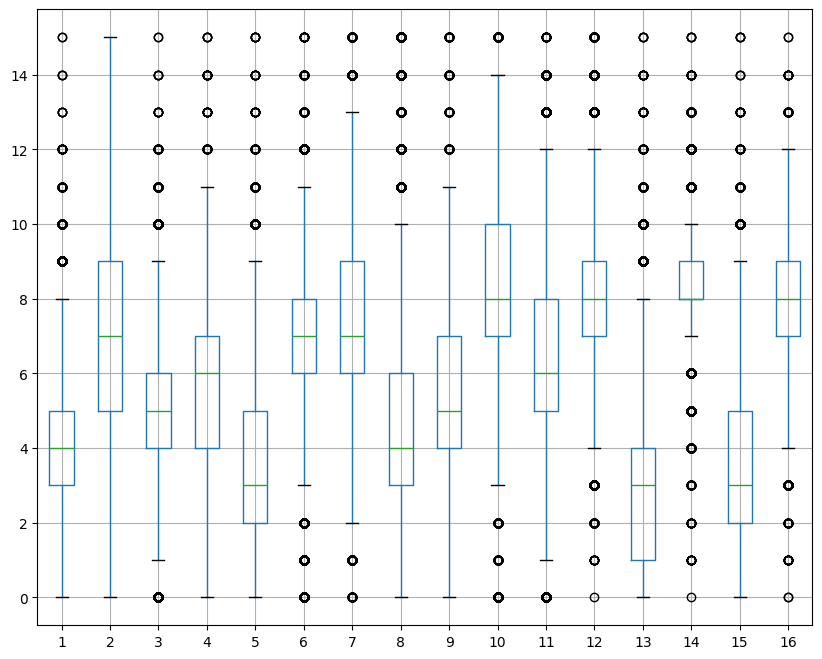

In [ ]:
df.boxplot(figsize=(10,8))

array([[<Axes: title={'center': '1'}>, <Axes: title={'center': '2'}>,
        <Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>],
       [<Axes: title={'center': '5'}>, <Axes: title={'center': '6'}>,
        <Axes: title={'center': '7'}>, <Axes: title={'center': '8'}>],
       [<Axes: title={'center': '9'}>, <Axes: title={'center': '10'}>,
        <Axes: title={'center': '11'}>, <Axes: title={'center': '12'}>],
       [<Axes: title={'center': '13'}>, <Axes: title={'center': '14'}>,
        <Axes: title={'center': '15'}>, <Axes: title={'center': '16'}>]],
      dtype=object)

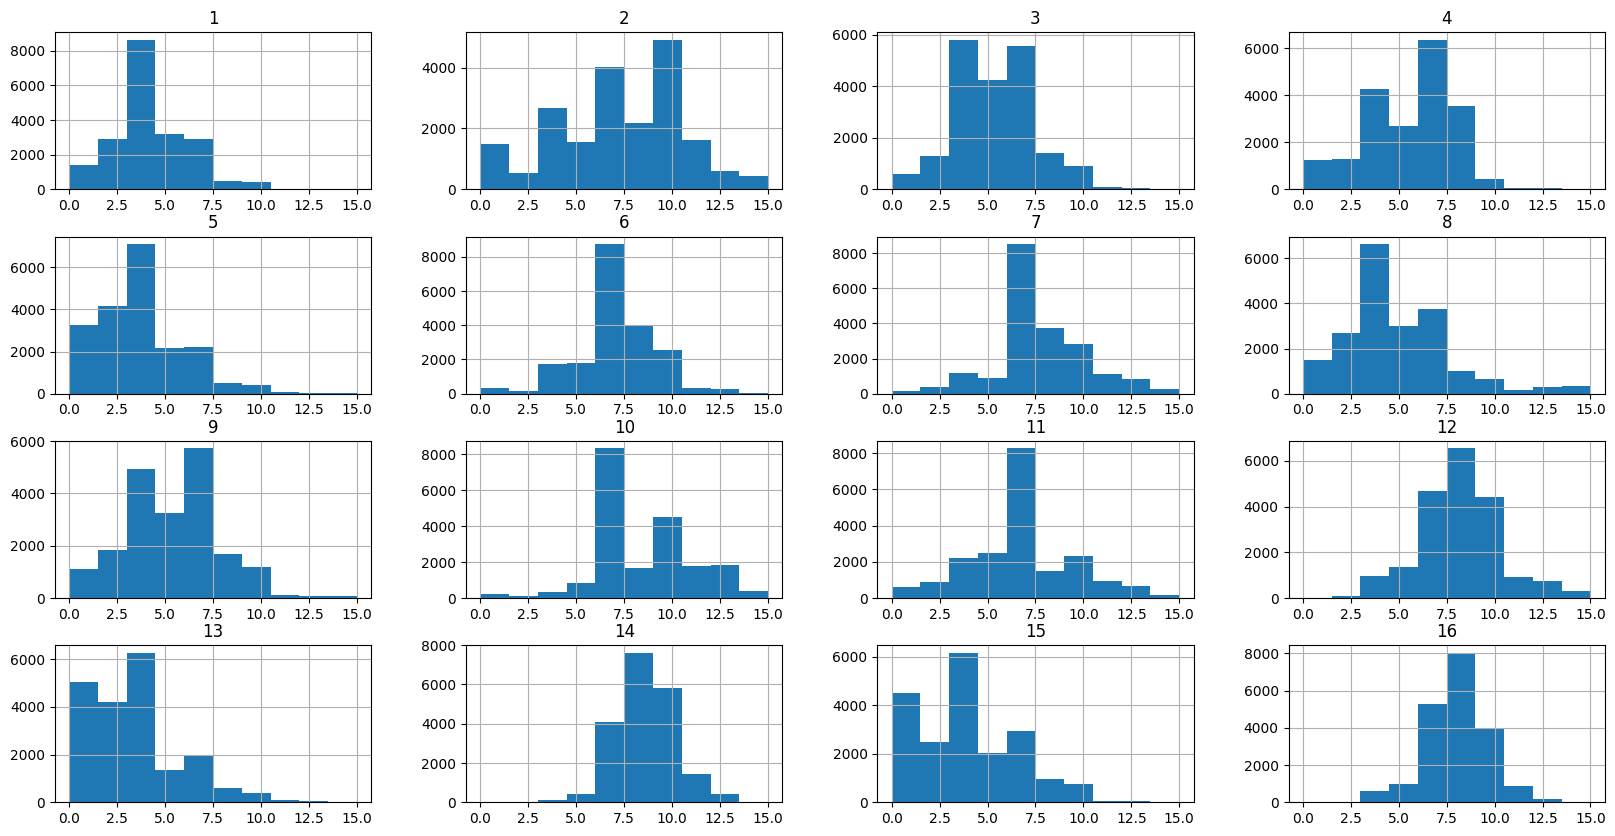

In [ ]:
df.hist(figsize=(20,10))

## handle duplicate data

In [ ]:
# Anggap 'df' adalah dataframe yang sudah di-load
# Cek jumlah duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat (persis): {duplicate_count}")

# Jika ingin MELIHAT data yang duplikat (opsional)
if duplicate_count > 0:
    print("\nContoh data duplikat:")
    # keep=False akan menampilkan semua baris yang kembar
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

# PROSES MENGHAPUS DUPLIKAT
# keep='first' artinya simpan 1, hapus sisanya.
df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)

print(f"\nJumlah baris sebelum: {len(df)}")
print(f"Jumlah baris sesudah: {len(df_clean)}")
print(f"Total dihapus: {len(df) - len(df_clean)}")

# Update variabel df
df = df_clean

Jumlah baris duplikat (persis): 1332

Contoh data duplikat:
      0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
6117   A   1   0   2   0   0   7   3   2   0   7   2   8   2   6   1   8
16857  A   1   0   2   0   0   7   3   2   0   7   2   8   2   6   1   8
1532   A   1   0   2   0   0   7   4   2   0   7   2   8   1   6   1   8
5752   A   1   0   2   0   0   7   4   2   0   7   2   8   1   6   1   8
3606   A   1   0   2   0   0   7   4   2   0   7   2   8   1   7   1   8
8575   A   1   0   2   0   0   7   4   2   0   7   2   8   1   7   1   8
13125  A   1   0   2   0   0   7   4   2   0   7   2   8   2   7   1   8
15651  A   1   0   2   0   0   7   4   2   0   7   2   8   2   7   1   8
19077  A   1   0   2   0   0   7   4   2   0   7   2   8   2   7   1   8
19595  A   1   0   2   0   0   7   4   2   0   7   2   8   2   7   1   8

Jumlah baris sebelum: 20000
Jumlah baris sesudah: 18668
Total dihapus: 1332


In [ ]:
feature_cols = [col for col in df.columns if col != 0]

conflicting_dupes = df.duplicated(subset=feature_cols, keep=False)

conflicting_data = df[conflicting_dupes].sort_values(by=feature_cols)

inconsistent_groups = conflicting_data.groupby(feature_cols)[0].nunique()
inconsistent_count = inconsistent_groups[inconsistent_groups > 1].count()

print(f"\nJumlah kasus data konflik (Fitur sama, Label beda): {inconsistent_count} grup")

if inconsistent_count > 0:
    print("Menghapus data konflik...")
    df_final = df.drop_duplicates(subset=feature_cols, keep=False).reset_index(drop=True)

    print(f"Jumlah data final bersih: {len(df_final)}")
    df = df_final
else:
    print("Tidak ada data konflik/inkonsisten.")


Jumlah kasus data konflik (Fitur sama, Label beda): 0 grup
Tidak ada data konflik/inkonsisten.


# Training data

In [ ]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Encoding target (A-Z -> 0-25) agar bisa masuk ke XGBoost/LGBM
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, train_size=16000, random_state=42)

# 4. Scaling (Penting untuk SVM, KNN, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### SVM Classifier

In [ ]:
# sudah menggunakan best param (best param didapatkan dari hasil tuning)
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', svm.SVC(C=10, gamma=0.1, kernel='rbf', probability=True, random_state=42))
])

### KNN Classifier

In [ ]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5, p=1, weights='distance'))
])

### Decision Tree Classifier

In [ ]:
# merupakan baseline
pipe_decision_tree = Pipeline(steps=[
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

### Random Forest Classfier

In [ ]:
pipe_rf = Pipeline(steps=[
    ('random_forest', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ))
])

## Ensemble Tree Classfier

### XGBoost Classifier

In [ ]:
pipe_xgb = Pipeline(steps=[
    ('xgb', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.2,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

### LightGBM Classifier

In [ ]:
pipe_lgbm = Pipeline(steps=[
    ('lgbm', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbose=-1   # menghilangkan log training agar output bersih
    ))
])

### Naive Bayes classifier

In [ ]:
pipe_nb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('nb', GaussianNB(var_smoothing=1e-09))
])

### Deep learning MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='tanh',
        alpha=0.001,
        max_iter=500,
        random_state=42
    ))
])

In [ ]:
# menggunakan training set
# 1. Strategy CV (Stratified agar proporsi huruf A-Z seimbang tiap fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. di list semua model
models = {
    "SVM": pipe_svm,
    "KNN": pipe_knn,
    "Decision Tree": pipe_decision_tree,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm,
    "Naive Bayes": pipe_nb,
    "MLP (Deep Learning)": pipe_mlp
}

print(f"{'Model Name':<25} | {'CV Accuracy (Mean)':<20} | {'Stability (Std Dev)'}")
print("-" * 65)

# 3. Loop untuk menghitung score masing-masing
results = []
names = []

for name, model in models.items():
    # Menghitung 5 scores berbeda untuk setiap model
    # n_jobs=-1 artinya menggunakan semua core CPU agar lebih cepat
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    # Simpan hasil untuk visualisasi nanti
    results.append(scores)
    names.append(name)

    # Print hasil format rapi
    print(f"{name:<25} | {scores.mean():.4f}               | +/- {scores.std():.4f}")

Model Name                | CV Accuracy (Mean)   | Stability (Std Dev)
-----------------------------------------------------------------
SVM                       | 0.9687               | +/- 0.0033
KNN                       | 0.9479               | +/- 0.0024
Decision Tree             | 0.8534               | +/- 0.0032
Random Forest             | 0.9559               | +/- 0.0027
XGBoost                   | 0.9589               | +/- 0.0023


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM                  | 0.9631               | +/- 0.0027
Naive Bayes               | 0.6346               | +/- 0.0042
MLP (Deep Learning)       | 0.9536               | +/- 0.0006


## Evaluation

=== DETAIL CLASSIFICATION REPORT (Dataset UCI) ===

Model: SVM
------------------------------
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       104
           B       0.96      0.97      0.96       110
           C       0.99      0.97      0.98        98
           D       0.94      0.97      0.96       118
           E       0.98      0.96      0.97       101
           F       0.94      0.99      0.97       100
           G       0.97      0.97      0.97       120
           H       0.93      0.96      0.95        99
           I       0.96      0.95      0.96        86
           J       1.00      0.97      0.99       102
           K       0.99      0.96      0.97       101
           L       0.98      0.97      0.98       117
           M       1.00      1.00      1.00        92
           N       0.98      0.98      0.98        91
           O       0.97      1.00      0.99        99
           P       0.99      0.97      0.

/tmp/ipython-input-4286504123.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Macro F1-Score', y='Model', data=df_results, palette='viridis')


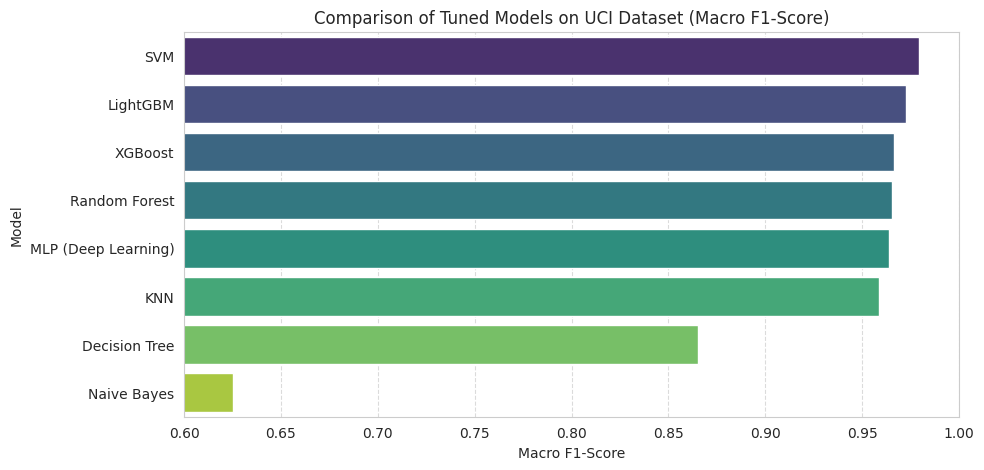

In [ ]:
# Wadah untuk menyimpan skor akhir
final_results = []

print("=== DETAIL CLASSIFICATION REPORT (Dataset UCI) ===")

for name, model in models.items():
    print(f"\nModel: {name}")
    print("-" * 30)

    model.fit(X_train, y_train)

    # 1. Prediksi Label dan Probabilitas (Probabilitas diperlukan untuk AUC)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) # Memerlukan probability=True pada SVM

    # 2. Hitung Metrik Evaluasi Dasar
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    # 3. Hitung Macro AUC (One-vs-Rest)
    # Metrik ini memvalidasi kemampuan pemisahan kelas
    roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # 4. Hitung Cross Validation (5-Fold) untuk Mean Accuracy & Stability
    # cv_results dihitung di sini agar spesifik untuk tiap model
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # 5. Simpan ke list untuk analisis akhir
    final_results.append({
        'Model': name,
        'CV Mean Accuracy': cv_mean,      # Akurasi Rata-rata
        'Stability (Std)': cv_std,         # Mengukur konsistensi fold
        'Accuracy': acc,                   # Akurasi pada data test
        'Macro F1-Score': f1_macro,        # Keseimbangan klasifikasi huruf
        'Macro AUC': roc_auc_macro         # Skor dari grafik ROC
    })

    # Cetak laporan detail Precision, Recall, F1 per huruf
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Buat DataFrame Perbandingan ---
# Diurutkan berdasarkan Macro F1-Score sesuai permintaan Anda
df_results = pd.DataFrame(final_results).sort_values(by='Macro F1-Score', ascending=False)

print("\n=== FINAL LEADERBOARD UCI (Sorted by F1-Score) ===")
print(df_results)

# --- Visualisasi Bar Chart Perbandingan F1 Score ---
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
# Gunakan palette yang jelas untuk membedakan model
sns.barplot(x='Macro F1-Score', y='Model', data=df_results, palette='viridis')
plt.title('Comparison of Tuned Models on UCI Dataset (Macro F1-Score)')
plt.xlim(0.6, 1.0) # Sesuaikan limit agar Naive Bayes tetap terlihat
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Menampilkan Confusion Matrix untuk Model Terbaik: LightGBM


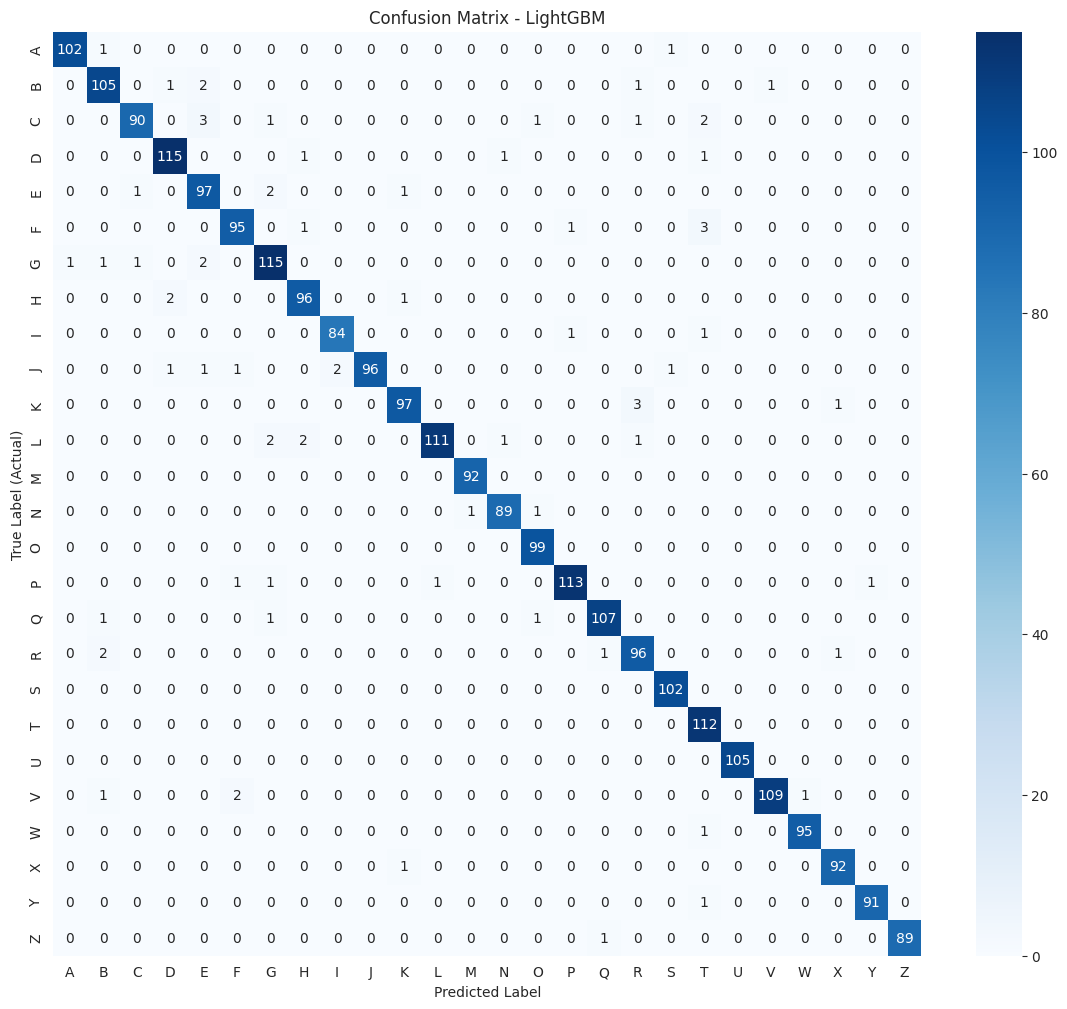

In [ ]:
def plot_confusion_matrix(model_name, model_object, X_test, y_test, classes):
    """
    Fungsi custom untuk plot confusion matrix 26x26 yang rapi
    """
    y_pred = model_object.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(14, 12)) # Ukuran besar agar huruf terbaca
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label (Actual)')
    plt.xlabel('Predicted Label')
    plt.show()

# CONTOH PENGGUNAAN:
# Ganti 'XGBoost' dengan nama model lain yang ada di best_models (misal 'SVM', 'Random Forest')
# Kita ambil model terbaik (urutan pertama di leaderboard)
best_model_name = df_results.iloc[1]['Model']
best_model_obj = models[best_model_name]

print(f"Menampilkan Confusion Matrix untuk Model Terbaik: {best_model_name}")
plot_confusion_matrix(best_model_name, best_model_obj, X_test, y_test, le.classes_)

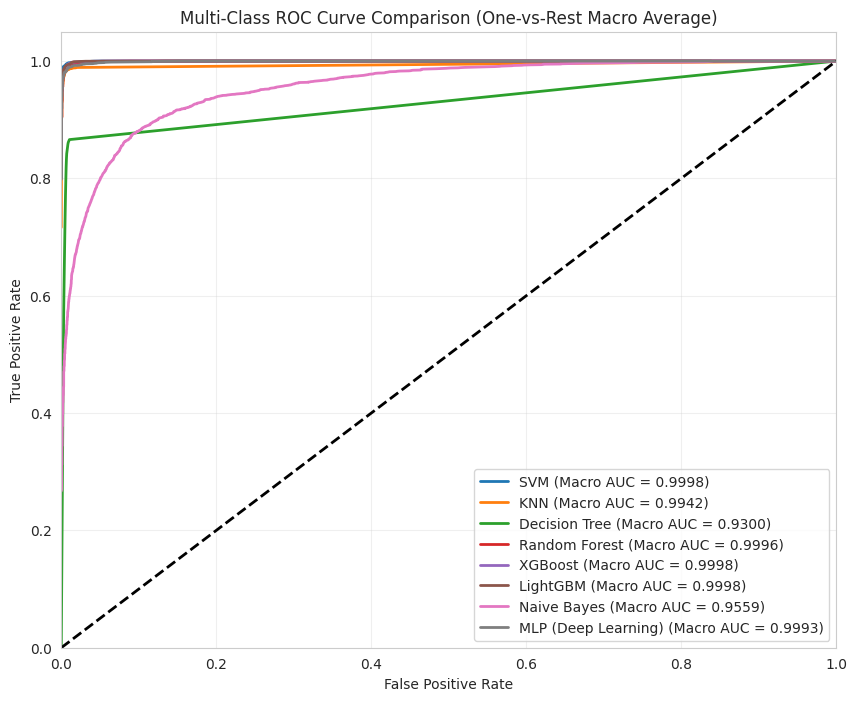

In [ ]:
# 1. Binarize Label Test (Ubah y_test jadi format One-Hot Encoding)
# Bentuknya jadi matriks (n_samples, 26) berisi 0 dan 1
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))

for name, model in models.items():

    # Cek apakah model support probability
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"): # Untuk SVM jika probability=False
        y_score = model.decision_function(X_test)
    else:
        print(f"Model {name} tidak support probability scores, skip ROC.")
        continue

    # 3. Hitung ROC untuk setiap kelas, lalu ambil rata-rata (Macro Average), untuk plot multi-class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute Macro-Average ROC curve and ROC area
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # 4. Plot Garis Model Tersebut
    plt.plot(all_fpr, mean_tpr,
             label=f'{name} (Macro AUC = {macro_auc:.4f})',
             linewidth=2)

# Dekorasi Plot
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Garis diagonal random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve Comparison (One-vs-Rest Macro Average)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Dataset Hugging Face

In [ ]:
from datasets import load_dataset

df_hf = load_dataset("pittawat/letter_recognition")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-92b9aa4d471d61(…):   0%|          | 0.00/7.41M [00:00<?, ?B/s]

data/test-00000-of-00001-bc8b28dacaaa708(…):   0%|          | 0.00/744k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2600 [00:00<?, ? examples/s]

In [ ]:
print(df_hf)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 26000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2600
    })
})


In [ ]:
def preprocess_hf_dataset(ds_split):
    """
    Mengubah format dataset Hugging Face (Image) menjadi Numpy Array (Tabular).
    Input: Dataset split (misal: dataset['train'])
    Output: X (Features), y (Labels)
    """
    images = []
    labels = []

    print(f"Memproses {len(ds_split)} data...")

    for item in ds_split:
        # 1. Ambil gambar dan ubah ke numpy array
        img_array = np.array(item['image'])

        # 2. FLATTENING: Ubah dari 28x28 (2D) menjadi 784 (1D vector)
        # Ini agar bisa masuk ke SVM/RF/XGBoost yang butuh input tabular
        img_flat = img_array.flatten()

        # 3. NORMALISASI MANUAL (Opsional di sini, tapi bagus untuk hemat memori)
        # Pixel 0-255 diubah jadi 0-1
        img_norm = img_flat / 255.0

        images.append(img_norm)
        labels.append(item['label'])

    return np.array(images), np.array(labels)

In [ ]:
print("\nMelakukan Preprocessing Data Train...")
X_train_hf, y_train_hf = preprocess_hf_dataset(df_hf['train'])

print("Melakukan Preprocessing Data Test...")
# Cek apakah ada split 'test', jika tidak ada kita split manual nanti
if 'test' in df_hf:
    X_test_hf, y_test_hf = preprocess_hf_dataset(df_hf['test'])
else:
    print("Split 'test' tidak ditemukan, akan melakukan split manual dari train.")
    from sklearn.model_selection import train_test_split
    X_train_hf, X_test_hf, y_train_hf, y_test_hf = train_test_split(
        X_train_hf, y_train_hf, test_size=0.2, random_state=42, stratify=y_train_hf
    )


Melakukan Preprocessing Data Train...
Memproses 26000 data...
Melakukan Preprocessing Data Test...
Memproses 2600 data...



=== HASIL PREPROCESSING ===
Shape X_train: (26000, 2352) (Jumlah Data, Jumlah Pixel/Fitur)
Shape y_train: (26000,)
Shape X_test : (2600, 2352)
Shape y_test : (2600,)
Contoh Label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


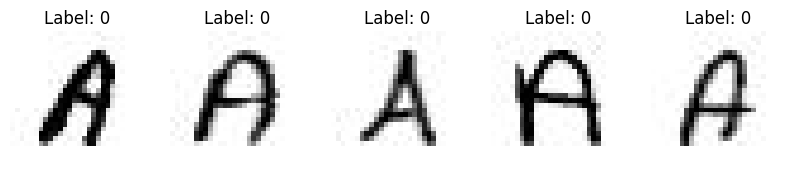

In [ ]:
print("\n=== HASIL PREPROCESSING ===")
print(f"Shape X_train: {X_train_hf.shape} (Jumlah Data, Jumlah Pixel/Fitur)")
print(f"Shape y_train: {y_train_hf.shape}")
print(f"Shape X_test : {X_test_hf.shape}")
print(f"Shape y_test : {y_test_hf.shape}")

# Pastikan labelnya integer (0-25)
print(f"Contoh Label: {np.unique(y_train_hf)}")

# --- VISUALISASI CONTOH DATA (Opsional) ---
# Untuk memastikan data benar
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Reshape kembali ke 28x28 untuk ditampilkan
    plt.imshow(X_train_hf[i].reshape(28, 28, 3), cmap='gray')
    plt.title(f"Label: {y_train_hf[i]}")
    plt.axis('off')
plt.show()

Jumlah fitur asli: 2352
Jumlah fitur setelah PCA (95% varians): 271


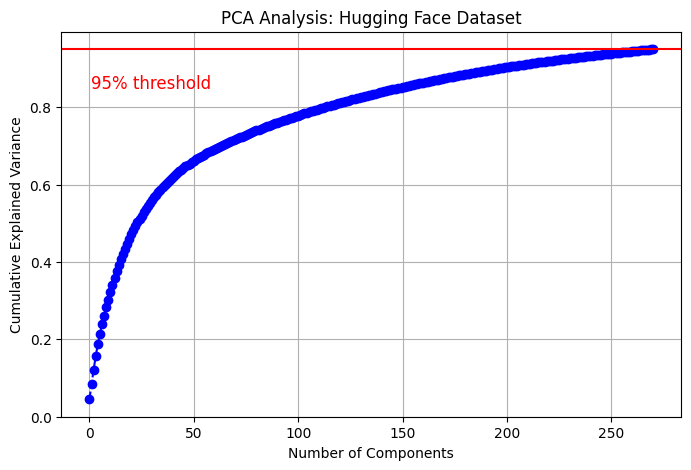

In [ ]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_hf_scaled = scaler.fit_transform(X_train_hf)
X_test_hf_scaled = scaler.transform(X_test_hf)

# 2. Inisialisasi PCA untuk mempertahankan 95% varians
pca = PCA(n_components=0.95, random_state=42)

# 3. Fit dan Transform
X_train_pca = pca.fit_transform(X_train_hf_scaled)
X_test_pca = pca.transform(X_test_hf_scaled)

print(f"Jumlah fitur asli: {X_train_hf_scaled.shape[1]}")
print(f"Jumlah fitur setelah PCA (95% varians): {pca.n_components_}")

# 4. Visualisasi Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Analysis: Hugging Face Dataset')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% threshold', color = 'red', fontsize=12)
plt.grid()
plt.show()

In [ ]:
# Tambahkan langkah 'pca' di antara 'scaler' dan 'clf'
pipe_svm_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)), # Reduksi dimensi otomatis
    ('clf', SVC(kernel='rbf', C=10, gamma=0.01, probability=True))
])

# Jalankan seperti biasa
pipe_svm_pca.fit(X_train_hf, y_train_hf)

Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('clf', SVC(C=10, gamma=0.01, probability=True))])

=== EVALUATION ON HUGGING FACE DATASET (WITH PCA 95%) ===
Processing: SVM...
Processing: KNN...
Processing: Decision Tree...
Processing: Random Forest...
Processing: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [00:05:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Processing: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing: Naive Bayes...
Processing: MLP (Deep Learning)...


/tmp/ipython-input-2443132562.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Macro F1-Score', y='Model', data=df_results_hf, palette='magma')


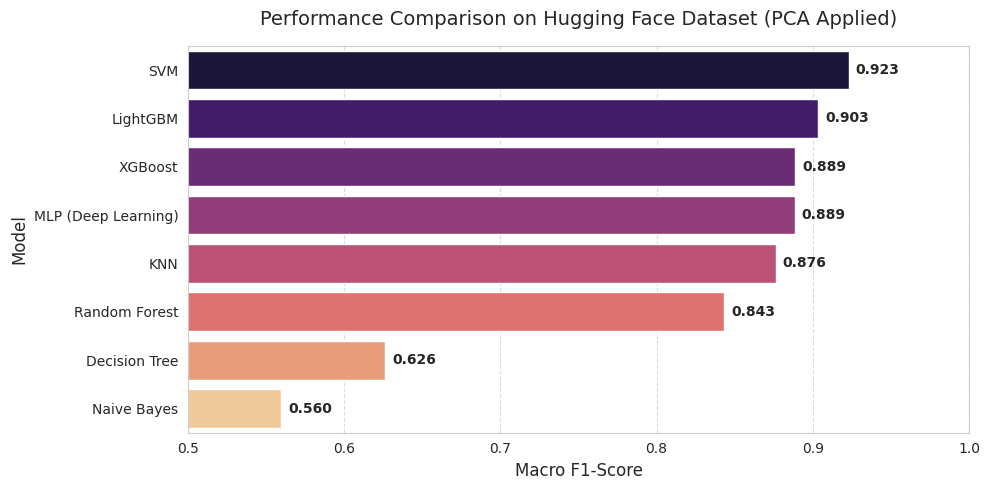

In [ ]:
# 1. Definisi Pipeline (Langkah 'scaler' dihapus karena X_pca sudah diskalakan)
models_macro = {
    "SVM": Pipeline([('clf', SVC(random_state=42))]),
    "KNN": Pipeline([('clf', KNeighborsClassifier())]),
    "Decision Tree": Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline([('clf', RandomForestClassifier(random_state=42))]),
    "XGBoost": Pipeline([('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))]),
    "LightGBM": Pipeline([('clf', LGBMClassifier(random_state=42, verbose=-1))]),
    "Naive Bayes": Pipeline([('clf', GaussianNB())]), # NB tidak butuh scaling, tapi PCA membantu
    "MLP (Deep Learning)": Pipeline([('clf', MLPClassifier(max_iter=500, random_state=42))])
}

# 2. Persiapkan CV dan List Penampung
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_results_hf = []

print("=== EVALUATION ON HUGGING FACE DATASET (WITH PCA 95%) ===")

# 3. Loop Evaluasi
for name, model in models_macro.items():
    print(f"Processing: {name}...")

    # Training menggunakan data PCA
    model.fit(X_train_pca, y_train_hf)

    # Prediksi menggunakan data PCA
    y_pred = model.predict(X_test_pca)

    # Hitung Metrik
    acc = accuracy_score(y_test_hf, y_pred)
    f1_macro = f1_score(y_test_hf, y_pred, average='macro')

    # Hitung CV (Stability) menggunakan data PCA
    # n_jobs=-1 agar lebih cepat
    cv_scores = cross_val_score(model, X_train_pca, y_train_hf, cv=cv, scoring='f1_macro', n_jobs=-1)

    # Simpan ke List
    final_results_hf.append({
        'Model': name,
        'Accuracy': acc,
        'Macro F1-Score': f1_macro,
        'CV Stability (Std)': cv_scores.std()
    })

# 4. Ubah ke DataFrame dan Urutkan
df_results_hf = pd.DataFrame(final_results_hf).sort_values(by='Macro F1-Score', ascending=False)

# --- VISUALISASI ---
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# Visualisasi menggunakan hasil PCA
ax = sns.barplot(x='Macro F1-Score', y='Model', data=df_results_hf, palette='magma')

plt.title('Performance Comparison on Hugging Face Dataset (PCA Applied)', fontsize=14, pad=15)
plt.xlabel('Macro F1-Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.5, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tambahkan label nilai di ujung bar
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-4117077545.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_trial = sns.barplot(x='Macro F1-Score', y='Model', data=df_results_hf, palette='cool')


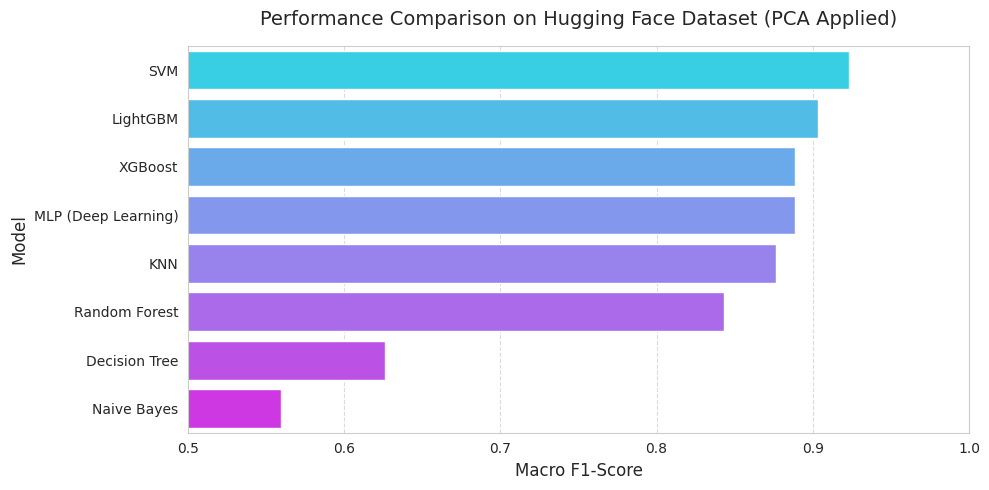

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# PILIHAN PALETTE (Pilih salah satu sesuai keinginan Anda):
# 1. 'plasma' : Ungu ke Kuning Terang (Sangat modern/Cyberpunk)
# 2. 'spring' : Pink ke Kuning (Sangat mencolok/High Energy)
# 3. 'YlOrRd' : Kuning-Oranye-Merah (Hangat dan sangat kontras)
# 4. 'cool'   : Biru Muda ke Pink (Segar dan futuristik)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# Visualisasi menggunakan hasil PCA
ax_trial = sns.barplot(x='Macro F1-Score', y='Model', data=df_results_hf, palette='cool')

plt.title('Performance Comparison on Hugging Face Dataset (PCA Applied)', fontsize=14, pad=15)
plt.xlabel('Macro F1-Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.5, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tambahkan label nilai di ujung bar
for p in ax_trial.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipe_svm_pca, X_train_hf, y_train_hf, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

KeyboardInterrupt: 

In [ ]:
# menggunakan training set hugging face
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model Name':<25} | {'CV Accuracy (Mean)':<20} | {'Stability (Std Dev)'}")
print("-" * 65)

# 3. Loop untuk menghitung score masing-masing
results_hf = []
names_hf = []

for name, model in models.items():
    # Menghitung 5 scores berbeda untuk setiap model
    # n_jobs=-1 artinya menggunakan semua core CPU agar lebih cepat
    scores = cross_val_score(model, X_train_hf, y_train_hf, cv=cv, scoring='accuracy', n_jobs=-1)

    # Simpan hasil untuk visualisasi nanti
    results_hf.append(scores)
    names_hf.append(name)

    print(f"{name:<25} | {scores.mean():.4f}               | +/- {scores.std():.4f}")

Model Name                | CV Accuracy (Mean)   | Stability (Std Dev)
-----------------------------------------------------------------


KeyboardInterrupt: 

## Evalutation Hugging Face dataset

In [ ]:
# Wadah untuk menyimpan skor akhir khusus Dataset HF
final_results_hf = []

print("=== DETAIL CLASSIFICATION REPORT Dataset HF (Pixel-Based) ===")

# Pastikan menggunakan model yang sudah di-fit pada data HF
for name, model in models.items():
    print(f"\nModel: {name}")
    print("-" * 30)

    model.fit(X_train_hf, y_train_hf)

    # 1. Prediksi Label dan Probabilitas
    y_pred = model.predict(X_test_hf)
    y_proba = model.predict_proba(X_test_hf) # Diperlukan untuk Macro AUC

    # 2. Hitung Metrik Evaluasi
    acc = accuracy_score(y_test_hf, y_pred)
    f1_macro = f1_score(y_test_hf, y_pred, average='macro')

    # Hitung Macro AUC (One-vs-Rest)
    roc_auc_macro = roc_auc_score(y_test_hf, y_proba, multi_class='ovr', average='macro')

    # 3. Hitung CV Accuracy & Stability (5-Fold pada data HF)
    # Ini menjawab metrik "Stability" yang Anda inginkan
    cv_scores = cross_val_score(model, X_train_hf, y_train_hf, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # 4. Simpan ke list
    final_results_hf.append({
        'Model': name,
        'CV Mean Accuracy': cv_mean,      # Performa rata-rata di HF
        'Stability (Std)': cv_std,         # Stabilitas model di HF
        'Accuracy': acc,                   # Akurasi global HF
        'Macro F1-Score': f1_macro,        # Keseimbangan klasifikasi HF
        'Macro AUC': roc_auc_macro         # Kemampuan pemisahan kelas HF
    })

    # Cetak laporan klasifikasi per huruf
    print(classification_report(y_test_hf, y_pred, target_names=le.classes_))

# --- Buat DataFrame Perbandingan HF ---
df_results_hf = pd.DataFrame(final_results_hf).sort_values(by='Accuracy', ascending=False)

print("\n=== FINAL LEADERBOARD HF (Sorted by Accuracy) ===")
print(df_results_hf)

# --- Visualisasi Bar Chart Perbandingan Accuracy ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=df_results_hf, palette='magma')
plt.title('Comparison of Models on Hugging Face Dataset (Accuracy)')
plt.xlim(0.5, 1.0) # Fokus pada range 50%-100%
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

=== DETAIL CLASSIFICATION REPORT Dataset HF (Pixel-Based) ===

Model: SVM
------------------------------


###

# visualization

## graph 1

In [ ]:
# Data diambil dari hasil Cross Validation (Mean Accuracy) yang Anda lampirkan
data = {
    'Model': [
        'SVM', 'KNN', 'Decision Tree', 'Random Forest',
        'XGBoost', 'LightGBM', 'Naive Bayes', 'MLP (Deep Learning)'
    ],
    df_uci = pd.DataFrame(final_results)
    df_hf = pd.DataFrame(final_results_hf)
}

# Buat DataFrame
df_analysis = pd.DataFrame(data)

# 2. HITUNG GAP & DROP RATE
# Rumus: (Score UCI - Score HF) / Score UCI
df_analysis['Drop_Rate (%)'] = ((df_analysis['UCI_Score'] - df_analysis['HF_Score']) / df_analysis['UCI_Score']) * 100
df_analysis['Average_Score'] = (df_analysis['UCI_Score'] + df_analysis['HF_Score']) / 2

# Urutkan berdasarkan Drop Rate terkecil (Paling Konsisten)
df_consistency = df_analysis.sort_values(by='Drop_Rate (%)', ascending=True)

# Urutkan berdasarkan Rata-rata Skor tertinggi (Paling Akurat)
df_accuracy = df_analysis.sort_values(by='Average_Score', ascending=False)

# 3. PREPARE DATA FOR PLOTTING (MELT)
# Mengubah format data agar bisa dibaca oleh Seaborn untuk Grouped Bar Chart
df_melted = df_analysis.melt(id_vars='Model', value_vars=['UCI_Score', 'HF_Score'],
                             var_name='Dataset', value_name='F1 Score / Accuracy')

# Rename label dataset agar lebih cantik di grafik
df_melted['Dataset'] = df_melted['Dataset'].replace({
    'UCI_Score': 'UCI (Feature-Based)',
    'HF_Score': 'Hugging Face (Pixel-Based)'
})

# 4. PLOTTING GROUPED BAR CHART
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Buat Bar Chart
ax = sns.barplot(
    data=df_melted,
    x='Model',
    y='F1 Score / Accuracy',
    hue='Dataset',
    palette='viridis'
)

# Kustomisasi Grafik
plt.title('Comparative Analysis: Ensemble vs Deep Learning (Consistency Test)', fontsize=14, fontweight='bold')
plt.ylabel('CV Score (Accuracy)', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0) # Fokuskan grafik di range 0.5 - 1.0 agar perbedaan terlihat
plt.legend(title='Dataset Source', loc='lower right')

# Tambahkan label angka di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# 5. PRINT HASIL ANALISIS (Untuk Laporan/Presentasi)
print("\n" + "="*50)
print("HASIL ANALISIS KONSISTENSI (DROP RATE)")
print("="*50)
print(df_consistency[['Model', 'UCI_Score', 'HF_Score', 'Drop_Rate (%)']].to_string(index=False))

print("\n" + "="*50)
print("HASIL ANALISIS AKURASI (RATA-RATA)")
print("="*50)
print(df_accuracy[['Model', 'Average_Score']].to_string(index=False))

# --- KESIMPULAN OTOMATIS ---
best_consistent = df_consistency.iloc[0]
best_accurate = df_accuracy.iloc[0]

print("\n" + "="*50)
print("KESIMPULAN AKHIR")
print("="*50)
print(f"1. Model Paling KONSISTEN (Robust): {best_consistent['Model']}")
print(f"   -> Hanya mengalami penurunan performa sebesar {best_consistent['Drop_Rate (%)']:.2f}% saat pindah dataset.")
print(f"2. Model Paling AKURAT (Best Overall): {best_accurate['Model']}")
print(f"   -> Memiliki rata-rata skor tertinggi yaitu {best_accurate['Average_Score']:.4f}.")

## graph 2

In [ ]:
# 1. SETUP DATA (Derived from provided results)
# Scores from UCI and Hugging Face
data = {
    'Model': ['SVM', 'KNN', 'Decision Tree', 'Random Forest',
              'XGBoost', 'LightGBM', 'Naive Bayes', 'MLP'],
    'UCI': [0.9369, 0.9354, 0.8534, 0.9554, 0.9535, 0.9579, 0.6346, 0.9429],
    'HF': [0.9311, 0.8677, 0.6697, 0.9135, 0.9140, 0.9272, 0.5500, 0.9141]
}

df = pd.DataFrame(data)

# 2. PLOTTING
plt.figure(figsize=(8, 10))

# Define colors (Highlighting SVM as the most consistent)
colors = {
    'SVM': '#d62728',          # Red for the consistency champion
    'Decision Tree': '#7f7f7f', # Gray for others
    'LightGBM': '#1f77b4',     # Blue for accuracy champion
    'Random Forest': '#7f7f7f',
    'XGBoost': '#7f7f7f',
    'MLP': '#7f7f7f',
    'KNN': '#7f7f7f',
    'Naive Bayes': '#7f7f7f'
}

# Draw lines
for i in range(len(df)):
    model = df.iloc[i]['Model']
    plt.plot([0, 1], [df.iloc[i]['UCI'], df.iloc[i]['HF']],
             marker='o', color=colors[model], linewidth=2 if colors[model] != '#7f7f7f' else 1)

    # Left Labels (UCI)
    plt.text(-0.05, df.iloc[i]['UCI'], f"{model}: {df.iloc[i]['UCI']:.3f}",
             ha='right', va='center', fontsize=10, fontweight='bold' if colors[model] != '#7f7f7f' else 'normal')

    # Right Labels (HF)
    plt.text(1.05, df.iloc[i]['HF'], f"{df.iloc[i]['HF']:.3f}",
             ha='left', va='center', fontsize=10, fontweight='bold' if colors[model] != '#7f7f7f' else 'normal')

# 3. CUSTOMIZATION
plt.xlim(-0.5, 1.5)
plt.ylim(0.5, 1.0)
plt.xticks([0, 1], ['Dataset 1\n(Feature-Based)', 'Dataset 2\n(Pixel-Based)'], fontsize=12, fontweight='bold')
plt.yticks([]) # Hide Y-axis as labels are on the lines
plt.title("Model Robustness & Consistency Test\n(UCI vs. Hugging Face Dataset)", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Remove border spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Side-by-Side Confusion Matrix

In [ ]:
# 1. SETUP FIGURE
# Membuat layout 1 baris 2 kolom
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# 2. PLOT SVM (Consistency Champion)
# Menggunakan data dari model yang sudah di-fit
y_pred_svm = pipe_svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=False, cmap='Blues', ax=ax1, cbar=True)
ax1.set_title('Consistency Champion: SVM\n(Min. Drop Rate: 0.62%)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label (Actual)', fontsize=12)
ax1.set_xticklabels(le.classes_)
ax1.set_yticklabels(le.classes_, rotation=0)

# 3. PLOT LightGBM (Accuracy Champion)
# Menggunakan data dari model yang sudah di-fit
y_pred_lgbm = models['LightGBM'].predict(X_test)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

sns.heatmap(cm_lgbm, annot=False, cmap='GnBu', ax=ax2, cbar=True)
ax2.set_title('Accuracy Champion: LightGBM\n(Best Overall Score: 0.9425)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label (Actual)', fontsize=12)
ax2.set_xticklabels(le.classes_)
ax2.set_yticklabels(le.classes_, rotation=0)

plt.suptitle('Error Analysis Comparison: Feature-Based Letter Recognition', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()